In [164]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import snntorch as snn
import matplotlib.pyplot as plt
import pandas as pd

from src import lif_utils as lu




Experiment setting


In [148]:
length = 24
steps = 8
object_width = 3
intensity = 0.30

buffer_size = 4
beta = 0.9
delay = buffer_size - 1




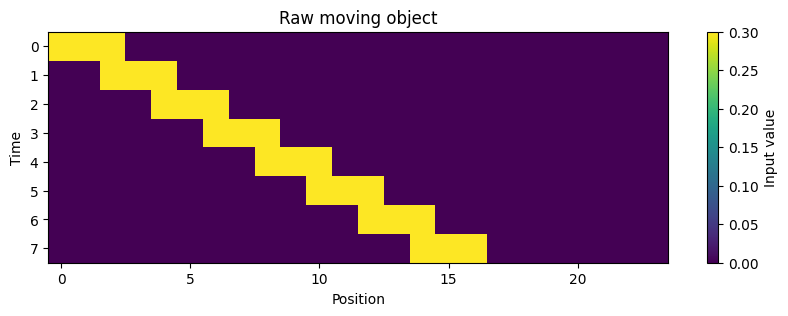

In [150]:
true_speed = 2

frames = lu.make_moving_1d_object(
    length=length,
    object_width=object_width,
    steps=steps,
    speed=true_speed,
    intensity=intensity,
)

plt.figure(figsize=(10, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Input value")
plt.show()




SUCCESS BELOW
SUccessful preiction of shape and location for any speed


In [158]:
true_speed = 2

frames = lu.make_moving_1d_object(
    length=length,
    object_width=object_width,
    steps=steps,
    speed=true_speed,
    intensity=intensity,
)





In [159]:
track = lu.delayed_shape_tracker_overlap_aware(
    frames,
    buffer_size=4,
    beta=0.9,
    max_speed=10,
)

print("estimated speed:", track["estimated_speed"])
print("delay:", track["delay"])
print("reconstruction mode:", track["reconstruction_mode"])

for t in range(frames.shape[0]):
    true_positions = torch.where(frames[t] > 0)[0].tolist()

    print(f"t={t}")
    print("true current positions:       ", true_positions)
    print("raw delayed spike positions:  ", track["raw_spike_shapes"][t])
    print("reconstructed delayed shape:  ", track["reconstructed_shapes"][t])
    print("predicted current positions:  ", track["predicted_shapes"][t])
    print()




estimated speed: 2
delay: 3
reconstruction mode: overlap_fragmented_rows
t=0
true current positions:        [0, 1, 2]
raw delayed spike positions:   []
reconstructed delayed shape:   []
predicted current positions:   []

t=1
true current positions:        [2, 3, 4]
raw delayed spike positions:   []
reconstructed delayed shape:   []
predicted current positions:   []

t=2
true current positions:        [4, 5, 6]
raw delayed spike positions:   [2]
reconstructed delayed shape:   []
predicted current positions:   []

t=3
true current positions:        [6, 7, 8]
raw delayed spike positions:   [0, 1, 4]
reconstructed delayed shape:   [0, 1, 2]
predicted current positions:   [6, 7, 8]

t=4
true current positions:        [8, 9, 10]
raw delayed spike positions:   [2, 3, 6]
reconstructed delayed shape:   [2, 3, 4]
predicted current positions:   [8, 9, 10]

t=5
true current positions:        [10, 11, 12]
raw delayed spike positions:   [4, 5, 8]
reconstructed delayed shape:   [4, 5, 6]
predicted cu

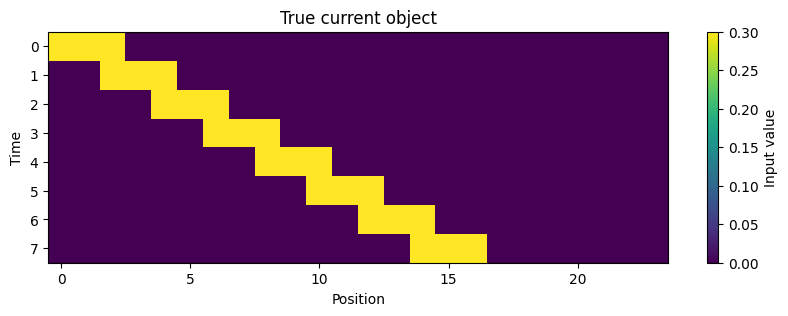

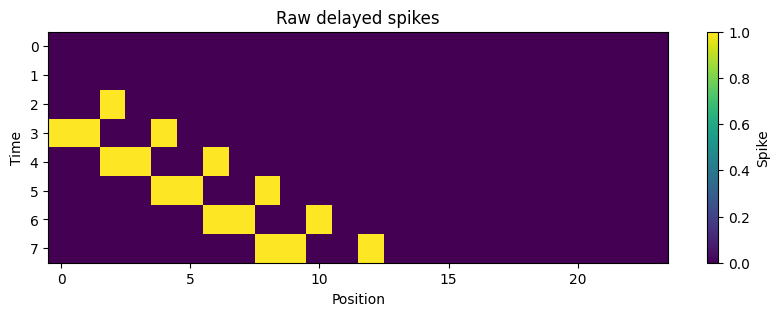

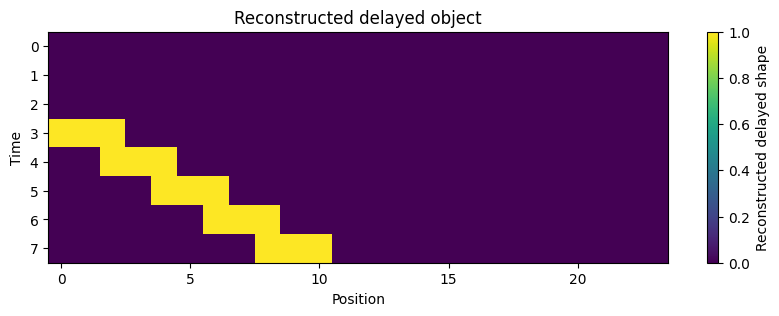

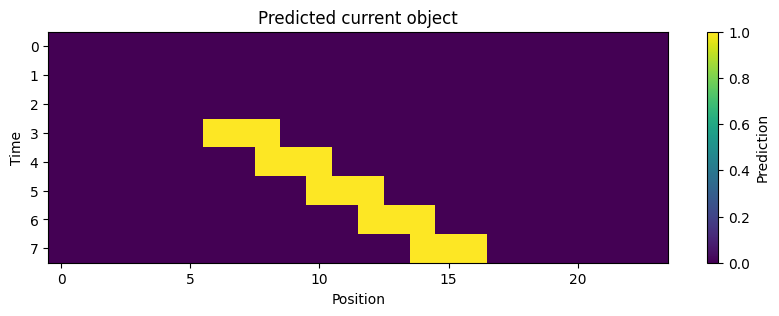

In [160]:
plt.figure(figsize=(10, 3))
plt.imshow(frames, aspect="auto")
plt.title("True current object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Input value")
plt.show()

lu.plot_spikes(
    track["spk_rec"],
    "Raw delayed spikes"
)

plt.figure(figsize=(10, 3))
plt.imshow(
    track["reconstructed_frame_matrix"],
    aspect="auto",
    vmin=0,
    vmax=1,
)
plt.title("Reconstructed delayed object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Reconstructed delayed shape")
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(
    track["predicted_frame_matrix"],
    aspect="auto",
    vmin=0,
    vmax=1,
)
plt.title("Predicted current object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Prediction")
plt.show()




Speed sweep

In [165]:
length = 24
steps = 8
object_width = 3
intensity = 0.30
buffer_size = 4
beta = 0.9

speeds = [1, 2, 3, 4, 5, 6]

rows = []

for true_speed in speeds:
    frames = lu.make_moving_1d_object(
        length=length,
        object_width=object_width,
        steps=steps,
        speed=true_speed,
        intensity=intensity,
    )

    track = lu.delayed_shape_tracker_overlap_aware(
        frames,
        buffer_size=buffer_size,
        beta=beta,
        max_speed=10,
    )

    eval_summary = lu.evaluate_predicted_shapes(
        frames,
        track["predicted_shapes"],
    )

    rows.append({
        "true_speed": true_speed,
        "estimated_speed": track["estimated_speed"],
        "reconstruction_mode": track["reconstruction_mode"],
        "mean_coverage": eval_summary["mean_coverage"],
        "mean_precision": eval_summary["mean_precision"],
        "num_exact_matches": eval_summary["num_exact_matches"],
    })

tracker_sweep_df = pd.DataFrame(rows)
tracker_sweep_df



,true_speed,estimated_speed,reconstruction_mode,mean_coverage,mean_precision,num_exact_matches
0,1,1,overlap_fragmented_rows,0.625,0.625,5
1,2,2,overlap_fragmented_rows,0.625,0.625,5
2,3,3,non_overlap_complete_rows,0.625,0.625,5
3,4,4,non_overlap_complete_rows,0.500,0.500,5
4,5,5,non_overlap_complete_rows,0.400,0.400,5
5,6,6,non_overlap_complete_rows,0.250,0.250,5


In [167]:
rows = []

for true_speed in speeds:
    frames = lu.make_moving_1d_object(
        length=length,
        object_width=object_width,
        steps=steps,
        speed=true_speed,
        intensity=intensity,
    )

    track = lu.delayed_shape_tracker_overlap_aware(
        frames,
        buffer_size=buffer_size,
        beta=beta,
        max_speed=10,
    )

    eval_summary = lu.evaluate_predicted_shapes_visible_only(
        frames,
        track["predicted_shapes"],
        expected_width=object_width,
    )

    rows.append({
        "true_speed": true_speed,
        "estimated_speed": track["estimated_speed"],
        "reconstruction_mode": track["reconstruction_mode"],
        "mean_coverage": eval_summary["mean_coverage"],
        "mean_precision": eval_summary["mean_precision"],
        "num_exact_matches": eval_summary["num_exact_matches"],
        "num_evaluated_frames": eval_summary["num_evaluated_frames"],
    })

tracker_visible_sweep_df = pd.DataFrame(rows)
tracker_visible_sweep_df



,true_speed,estimated_speed,reconstruction_mode,mean_coverage,mean_precision,num_exact_matches,num_evaluated_frames
0,1,1,overlap_fragmented_rows,0.625,0.625,5,8
1,2,2,overlap_fragmented_rows,0.625,0.625,5,8
2,3,3,non_overlap_complete_rows,0.625,0.625,5,8
3,4,4,non_overlap_complete_rows,0.500,0.500,3,6
4,5,5,non_overlap_complete_rows,0.400,0.400,2,5
5,6,6,non_overlap_complete_rows,0.250,0.250,1,4


Now I woudl like to have to object start from any edge

In [184]:
frames = lu.make_moving_1d_object_from_edge_fully_visible(
    length=24,
    object_width=3,
    steps=8,
    edge="right",
    speed=1,
    intensity=0.30,
)

track = lu.delayed_shape_tracker_overlap_aware(
    frames,
    buffer_size=4,
    beta=0.9,
    max_speed=10,
)

print("estimated speed:", track["estimated_speed"])
print("delay:", track["delay"])
print("reconstruction mode:", track["reconstruction_mode"])



estimated speed: -1
delay: 3
reconstruction mode: overlap_fragmented_rows


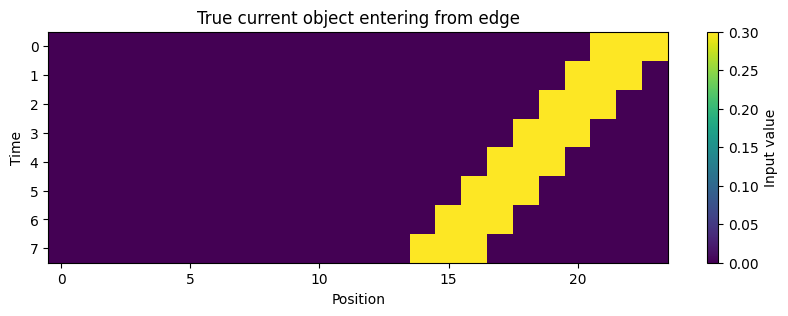

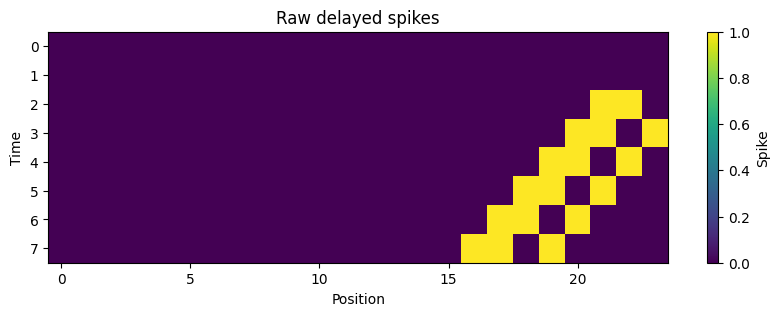

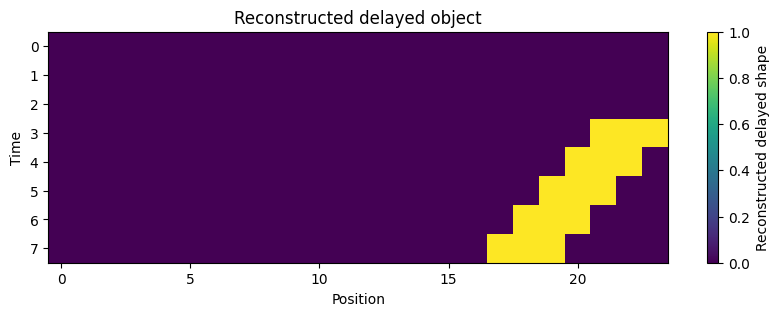

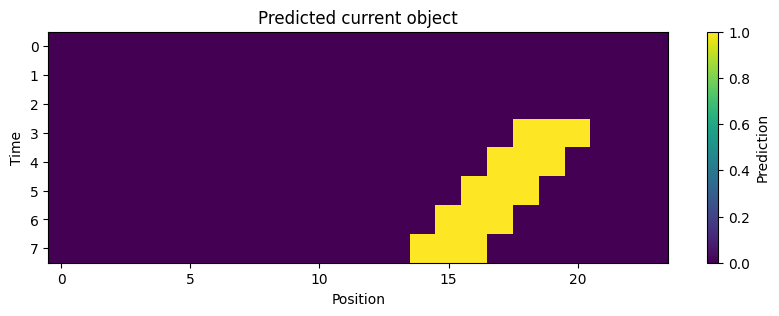

In [185]:
plt.figure(figsize=(10, 3))
plt.imshow(frames, aspect="auto")
plt.title("True current object entering from edge")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Input value")
plt.show()

lu.plot_spikes(
    track["spk_rec"],
    "Raw delayed spikes"
)

plt.figure(figsize=(10, 3))
plt.imshow(
    track["reconstructed_frame_matrix"],
    aspect="auto",
    vmin=0,
    vmax=1,
)
plt.title("Reconstructed delayed object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Reconstructed delayed shape")
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(
    track["predicted_frame_matrix"],
    aspect="auto",
    vmin=0,
    vmax=1,
)
plt.title("Predicted current object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar(label="Prediction")
plt.show()



In [188]:
length = 24
object_width = 3
steps = 10
intensity = 0.30
buffer_size = 4
beta = 0.9

edges = ["left", "right"]
speeds = [1, 2, 3, 4, 5, 6]

rows = []

for edge in edges:
    for true_speed in speeds:
        frames = lu.make_moving_1d_object_from_edge_fully_visible(
            length=length,
            object_width=object_width,
            steps=steps,
            edge=edge,
            speed=true_speed,
            intensity=intensity,
        )

        track = lu.delayed_shape_tracker_overlap_aware(
            frames,
            buffer_size=buffer_size,
            beta=beta,
            max_speed=10,
        )

        eval_summary = lu.evaluate_predicted_shapes_visible_only(
            frames,
            track["predicted_shapes"],
            expected_width=object_width,
        )

        expected_signed_speed = true_speed if edge == "left" else -true_speed

        rows.append({
            "edge": edge,
            "true_speed": expected_signed_speed,
            "estimated_speed": track["estimated_speed"],
            "reconstruction_mode": track["reconstruction_mode"],
            "mean_coverage": eval_summary["mean_coverage"],
            "mean_precision": eval_summary["mean_precision"],
            "num_exact_matches": eval_summary["num_exact_matches"],
            "num_evaluated_frames": eval_summary["num_evaluated_frames"],
        })

edge_sweep_df = pd.DataFrame(rows)
edge_sweep_df



,edge,true_speed,estimated_speed,reconstruction_mode,mean_coverage,mean_precision,num_exact_matches,num_evaluated_frames
0,left,1,1,overlap_fragmented_rows,0.700,0.700,7,10
1,left,2,2,overlap_fragmented_rows,0.700,0.700,7,10
2,left,3,3,non_overlap_complete_rows,0.625,0.625,5,8
3,left,4,4,non_overlap_complete_rows,0.500,0.500,3,6
4,left,5,5,non_overlap_complete_rows,0.400,0.400,2,5
5,left,6,6,non_overlap_complete_rows,0.250,0.250,1,4
6,right,-1,-1,overlap_fragmented_rows,0.700,0.700,7,10
7,right,-2,-2,overlap_fragmented_rows,0.700,0.700,7,10
8,right,-3,-3,non_overlap_complete_rows,0.625,0.625,5,8
9,right,-4,-4,non_overlap_complete_rows,0.500,0.500,3,6


I was able to predit object shape and location with this 1-d model but now 2 new problems arise:
1) The object can cross FOV gradually and that creates a new set of problems
2) Variable speeds

I came to a conclusion that this toy model is no longer viable as in a real biological scenario every pixel doesn't have 0.3 signal. If an object is slow enough to where it doesnt move more than its onw body radius we probably dont need a memory buffer to identify and trakc it anyway. 

Need to break the problem into 3:
1) Did an object pass (detection)
2) What passed (shape recognition)
3) Where is it now (cuurent location)

Let
r = speed / object_width

r < 1:
  overlapping observations
  local temporal integration is useful

r ≈ 1:
  transition regime
  fragmentation/overlap artifacts appear

r > 1:
  non-overlapping fast motion
  delayed hard buffer and prediction work well

Summary:
The difficulty is not that object pixels are intrinsically weak. The difficulty is that fast motion prevents the system from forming a stable spatial representation before the object changes position. A short-term buffer can recover delayed shape information. Velocity estimation can then project the delayed representation forward. Slow objects can be handled by ordinary temporal integration, while fast objects require delayed reconstruction and prediction.